In [1]:
import sklearn
import sklearn.datasets
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import AdamOptimizer
import matplotlib.pyplot as plt

In [2]:
def load_wine(split_ratio = 0.5):
    feat, label = sklearn.datasets.load_wine(return_X_y=True)

    # normalization
    feat = np.pi * (feat - np.min(feat, axis=0, keepdims=True)) / np.ptp(feat, axis=0, keepdims=True)

    index_c0 = label == 0
    index_c1 = label == 1

    label = label * 2 - 1

    n_c0 = sum(index_c0)
    n_c1 = sum(index_c1)

    X_train = np.concatenate((feat[index_c0][:int(split_ratio*n_c0)], feat[index_c1][:int(split_ratio*n_c1)]), axis=0)
    y_train = np.concatenate((label[index_c0][:int(split_ratio*n_c0)], label[index_c1][:int(split_ratio*n_c1)]), axis=0)
    X_test = np.concatenate((feat[index_c0][int(split_ratio*n_c0):], feat[index_c1][int(split_ratio*n_c1):]), axis=0)
    y_test = np.concatenate((label[index_c0][int(split_ratio*n_c0):], label[index_c1][int(split_ratio*n_c1):]), axis=0)

    return X_train, y_train, X_test, y_test
X_train, y_train, X_test, y_test = load_wine()

C:\Users\g.melis\AppData\Local\Temp\ipykernel_29588\1568800584.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(wine_tsne[indices, 0], wine_tsne[indices, 1], edgecolor='black', cmap='coolwarm', s=20, label=f'Class {label}')


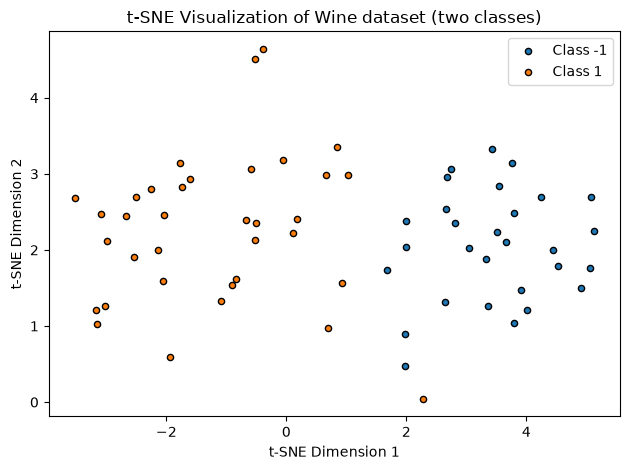

In [3]:
def visualize_dataset(X, y):
    from sklearn.manifold import TSNE

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    wine_tsne = tsne.fit_transform(X)
    for label in np.unique(y):
        indices = y == label
        plt.scatter(wine_tsne[indices, 0], wine_tsne[indices, 1], edgecolor='black', cmap='coolwarm', s=20, label=f'Class {label}')

    # Add labels and legend
    plt.title("t-SNE Visualization of Wine dataset (two classes)")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()

    plt.tight_layout()
    plt.show()
visualize_dataset(X_train, y_train)

In [4]:
def data_encoding(x):
    n_qubit = len(x)
    qml.AngleEmbedding(features =x , wires = range(n_qubit) , rotation ="X")
    for i in range(n_qubit):
        if i+1 < n_qubit:
            qml.CNOT(wires=[i, i+1])

In [5]:
def classifier(param, x=None):
    data_encoding(x)
    n_layer, n_qubit = param.shape[0], param.shape[1]
    for i in range(n_layer):
        for j in range(n_qubit):
            qml.Rot(param[i, j, 0], param[i, j, 1], param[i, j, 2], wires=j)
        for j in range(n_qubit):
            if j+1 < n_qubit:
                qml.CNOT(wires=[j, j+1])
    return qml.expval(qml.PauliZ(0))

n_qubit = X_train.shape[1]
dev = qml.device('default.qubit', wires=n_qubit)
circuit = qml.QNode(classifier, dev)

C:\Users\g.melis\AppData\Local\Temp\ipykernel_29588\2588758708.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


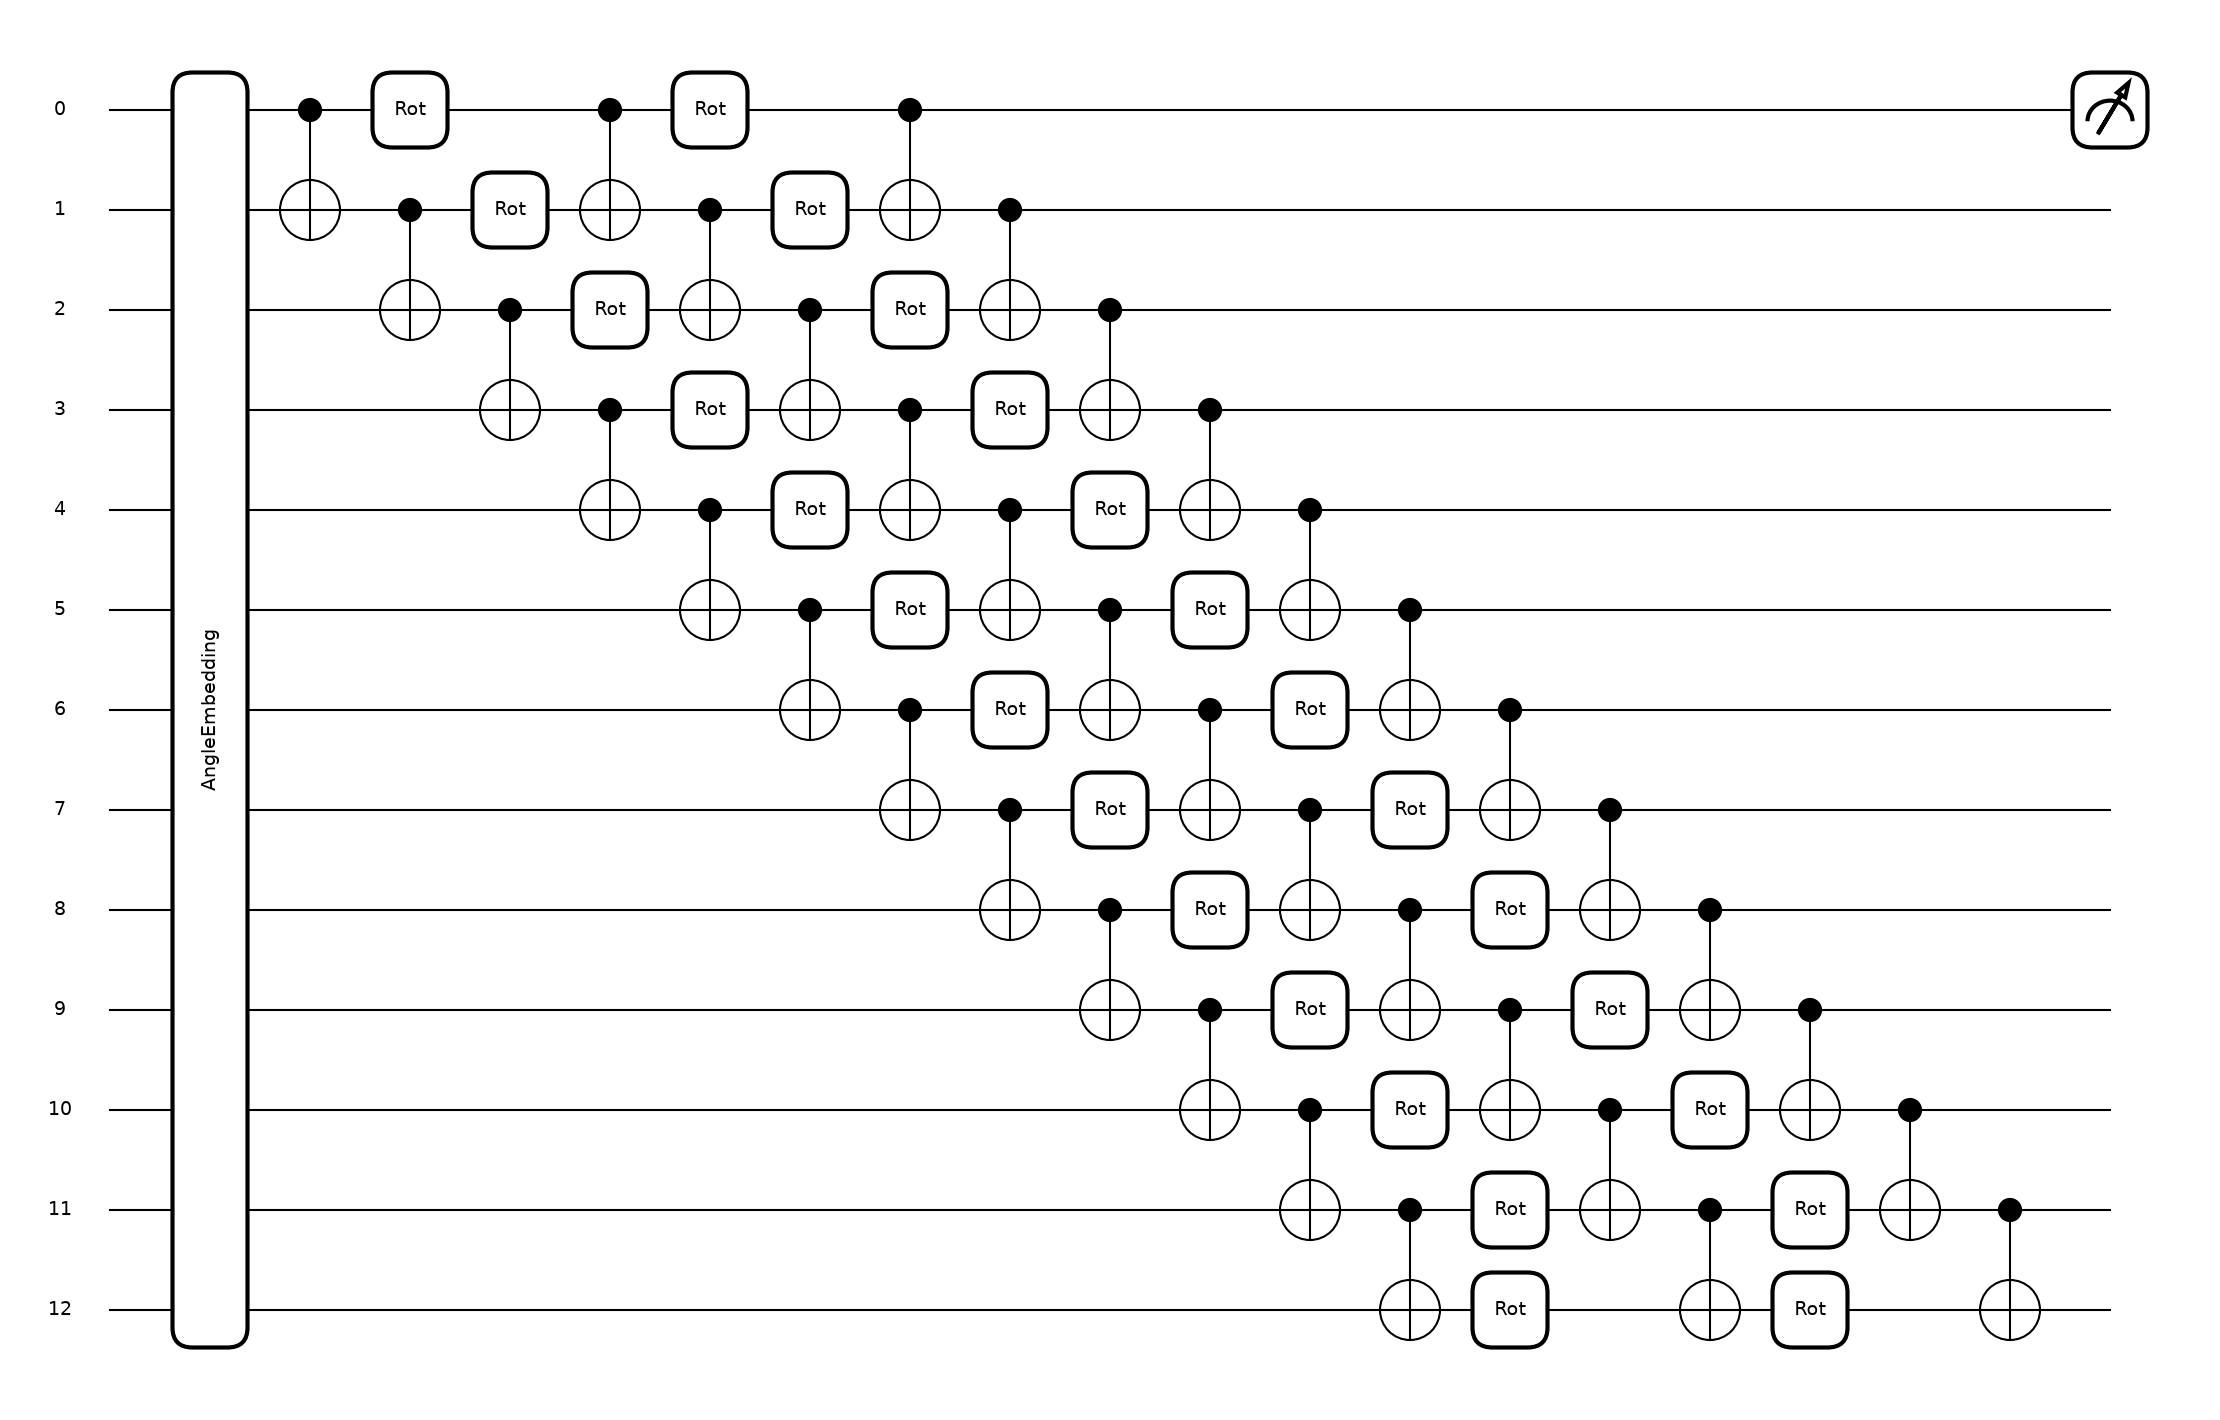

In [6]:
fig, ax = qml.draw_mpl(circuit)(np.pi * np.random.randn(2, n_qubit, 3), X_train[0])
fig.show()

In [7]:
def mse_loss(predict, label):
    return np.mean((predict - label)**2)

def cost(param, circuit, X, y):
    exp = []
    for i in range(len(X)):
        pred = circuit(param, x=X[i])
        exp.append(pred)
    return mse_loss(np.array(exp), y)

In [8]:
def accuracy(predicts, labels):
    assert len(predicts) == len(labels)
    return np.sum((np.sign(predicts)*labels+1)/2)/len(predicts)

In [9]:
n_layer = 4
param = np.pi * np.random.randn(n_layer, n_qubit, 3)

In [10]:
lr = 0.01
opt = AdamOptimizer(lr)
batch_size = 4

n_epoch = 50
cost_train, cost_test, acc_train, acc_test = [], [], [], []
for i in range(n_epoch):
    index = np.random.permutation(len(X_train))
    feat_train, label_train = X_train[index], y_train[index]
    for j in range(0, len(X_train), batch_size):
        feat_train_batch = feat_train[j*batch_size:(j+1)*batch_size]
        label_train_batch = label_train[j*batch_size:(j+1)*batch_size]
        param = opt.step(lambda v: cost(v, circuit, feat_train_batch, label_train_batch), param)
    
    # compute cost
    cost_train.append(cost(param, circuit, X_train, y_train))
    cost_test.append(cost(param, circuit, X_test, y_test))

    # compute accuracy
    pred_train = []
    for j in range(len(X_train)):
        pred_train.append(circuit(param, x=X_train[j]))
    acc_train.append(accuracy(np.array(pred_train), y_train))

    pred_test = []
    for j in range(len(X_test)):
        pred_test.append(circuit(param, x=X_test[j]))
    acc_test.append(accuracy(np.array(pred_test), y_test))

c:\Users\g.melis\OneDrive - AXIS ALTERNATIVES\Bureau\Quantum pricing\Code\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3822: RuntimeWarning: Mean of empty slice
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
c:\Users\g.melis\OneDrive - AXIS ALTERNATIVES\Bureau\Quantum pricing\Code\.venv\Lib\site-packages\pennylane\numpy\tensor.py:157: RuntimeWarning: invalid value encountered in divide
  res = super().__array_ufunc__(ufunc, method, *args, **kwargs)
c:\Users\g.melis\OneDrive - AXIS ALTERNATIVES\Bureau\Quantum pricing\Code\.venv\Lib\site-packages\autograd\tracer.py:16: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


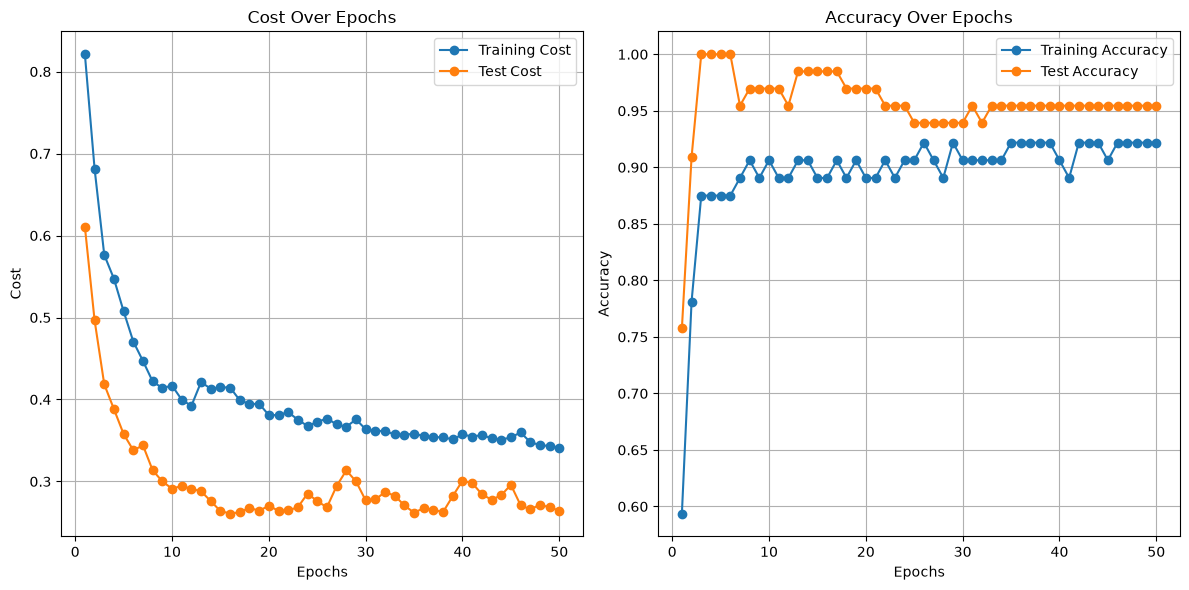

In [11]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
epochs = np.arange(n_epoch) + 1
plt.plot(epochs, cost_train, label='Training Cost', marker='o')
plt.plot(epochs, cost_test, label='Test Cost', marker='o')
plt.title('Cost Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.legend()
plt.grid()

# Plot training and test accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, acc_train, label='Training Accuracy', marker='o')
plt.plot(epochs, acc_test, label='Test Accuracy', marker='o')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()